### Speech Example

Trimming Evo from 11 → 10 iterations


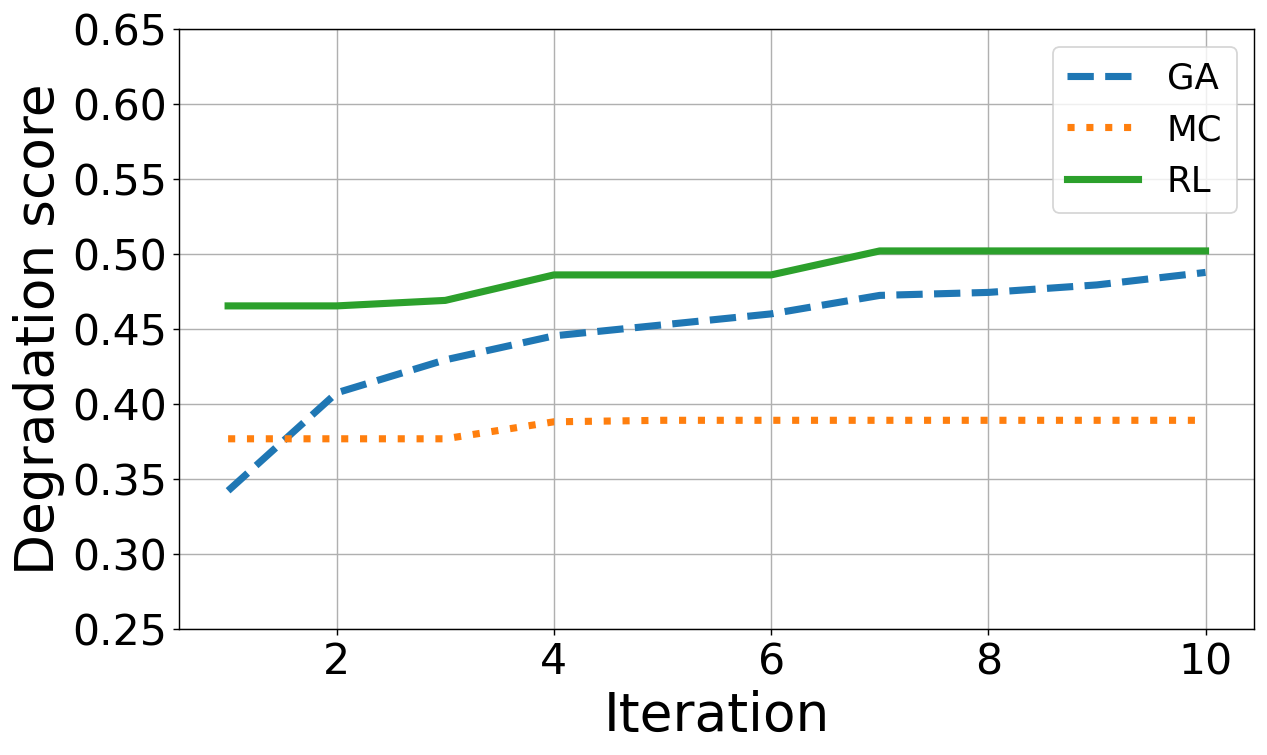

In [6]:
import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ===================== CONFIG =====================

# Folder where your *BestResults* CSVs are stored
# e.g. base_dir = "./Thesis.Related"
base_dir = "./Data/Speech/"

# Regex pattern to parse optimiser + dataset from filenames
# Example filename:
#   RL_Data_BestResults_202511051532_EnglishMale.csv
pattern = re.compile(
    r"^(RL|Evo|MC)_Data_BestResults_\d+_"
    r"(EnglishMale|SpeechwithMusic|Germanspeech)\.csv$"
)


# ===================== LOAD FILES =====================

opt_data = {}  # optimiser -> dataset -> 1D np.array of scores

for path in glob.glob(os.path.join(base_dir, "*_Data_BestResults_*.csv")):
    fname = os.path.basename(path)
    m = pattern.match(fname)
    if not m:
        # Skip files that don't match the naming convention
        continue

    optimiser, dataset = m.group(1), m.group(2)
    df = pd.read_csv(path)

    if "score" not in df.columns:
        raise ValueError(f"'score' column not found in {fname}")

    scores = df["score"].to_numpy()

    opt_data.setdefault(optimiser, {})[dataset] = scores


# ===================== HELPER: BEST-UNTIL-CURRENT =====================

def best_until(scores: np.ndarray) -> np.ndarray:
    """
    Turn a per-iteration score array into a 'best so far' curve.
    """
    return np.maximum.accumulate(scores)


# ===================== COMPUTE AVERAGED CURVES =====================

avg_curves = {}         # optimiser -> 1D np.array (averaged best-until curve)
per_dataset_curves = {} # optimiser -> dataset -> 1D np.array (best-until curve)

for optimiser, ds_dict in opt_data.items():
    if len(ds_dict) == 0:
        continue

    # Compute best-until curves per dataset
    ds_curves = {}
    for dataset, scores in ds_dict.items():
        ds_curves[dataset] = best_until(scores)

    # Align lengths: use the minimum length across datasets
    lengths = [len(c) for c in ds_curves.values()]
    L = min(lengths)

    # Stack truncated curves for averaging
    stacked = np.vstack([c[:L] for c in ds_curves.values()])
    avg_curve = stacked.mean(axis=0)

    avg_curves[optimiser] = avg_curve
    per_dataset_curves[optimiser] = {d: c[:L] for d, c in ds_curves.items()}

if "Evo" in avg_curves:
    evo_len = len(avg_curves["Evo"])

    # determine common minimum length
    common_length = min(len(avg_curves["RL"]), len(avg_curves["MC"]))

    if evo_len > common_length:
        print(f"Trimming Evo from {evo_len} → {common_length} iterations")
        avg_curves["Evo"] = avg_curves["Evo"][:common_length]

        # also trim per-dataset Evo curves (important!!)
        for ds in per_dataset_curves["Evo"]:
            per_dataset_curves["Evo"][ds] = per_dataset_curves["Evo"][ds][:common_length]


# ===================== PLOT AVERAGED CURVES =====================

plt.figure(figsize=(10,6), dpi=128)

# Line styles per optimiser
line_styles = {
    "RL": "-",
    "Evo": "--",
    "MC": ":"
}

# Legend remapping
legend_map = {
    "RL": "RL",
    "Evo": "GA",
    "MC": "MC"
}

for optimiser, curve in sorted(avg_curves.items()):
    iters = np.arange(1, len(curve) + 1)
    style = line_styles.get(optimiser, "-")
    label = legend_map.get(optimiser, optimiser)
    plt.plot(iters, curve, style, linewidth=4, label=label)

plt.xlabel("Iteration",fontsize=30)
plt.ylabel("Degradation score",fontsize=30)
plt.ylim(0.25, 0.65)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
#plt.title("Average best-until-current-iteration across datasets (Speech)")
plt.grid(True)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


# ===================== (OPTIONAL) EXPORT RESULTS =====================

# If you want the numeric values for further analysis:
all_avg_df = []
for optimiser, curve in avg_curves.items():
    iters = np.arange(1, len(curve) + 1)
    tmp = pd.DataFrame({
        "optimiser": optimiser,
        "iteration": iters,
        "avg_best_until": curve,
    })
    all_avg_df.append(tmp)

all_avg_df = pd.concat(all_avg_df, ignore_index=True)
# Example: save to CSV
# all_avg_df.to_csv("Average_BestUntil_AllOptimisers.csv", index=False)


### MUSIC EXAMPLE

Trimming RL from 11 → 10 iterations
Trimming Evo from 11 → 10 iterations

=== Maximum value for each dataset (after adjustments) ===

Optimiser: Evo
  Hendrix: 0.415000
    Best row: {'score': 0.415, 'Hum': 15.93, 'Hiss': 30.23, 'CL': 1.87, 'Thre': -14.94, 'Ratio': 6.91, 'Attk': 0.1, 'Release': 63.31}
  Rock: 0.371000
    Best row: {'score': 0.371, 'Hum': 16.4, 'Hiss': 30.27, 'CL': 1.94, 'Thre': -13.88, 'Ratio': 9.76, 'Attk': 0.12, 'Release': 54.76}
  Punk: 0.305000
    Best row: {'score': 0.305, 'Hum': 15.04, 'Hiss': 30.89, 'CL': 1.87, 'Thre': -14.31, 'Ratio': 9.81, 'Attk': 0.99, 'Release': 79.92}
  Grunge: 0.434000
    Best row: {'score': 0.434, 'Hum': 17.35, 'Hiss': 31.25, 'CL': 1.81, 'Thre': -13.96, 'Ratio': 9.06, 'Attk': 0.13, 'Release': 71.76}
  Britpop: 0.398000
    Best row: {'score': 0.398, 'Hum': 15.63, 'Hiss': 30.43, 'CL': 1.85, 'Thre': -13.76, 'Ratio': 9.54, 'Attk': 0.46, 'Release': 52.71}

Optimiser: MC
  Hendrix: 0.347000
    Best row: {'score': 0.347, 'Hum': 15.13, 'Hiss

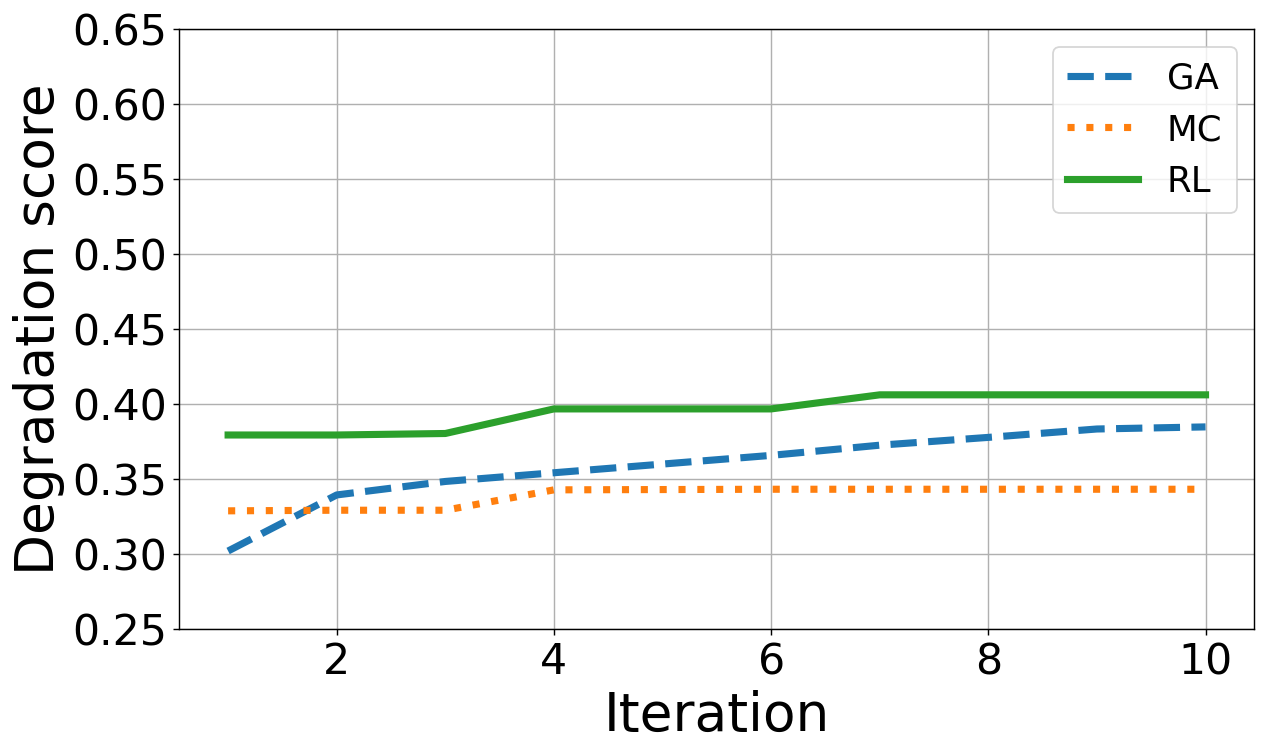

In [5]:
import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ===================== CONFIG =====================

# Folder where your *BestResults* CSVs are stored
# e.g. base_dir = "./Thesis.Related"
base_dir = "./Data/Music/"
DATASET_ORDER = ["Hendrix", "Rock", "Punk", "Grunge", "Britpop"]

# Regex pattern to parse optimiser + dataset from filenames
# Example filename:
#   RL_Data_BestResults_202511051532_EnglishMale.csv
pattern = re.compile(
    r"^(RL|Evo|MC)_Data_BestResults_\d+_"
    r"(Hendrix|Rock|Punk|Grunge|Britpop)\.csv$"
)


# ===================== HELPER FUNCTIONS =====================

def compress_to_max_len(scores: np.ndarray, max_len: int = 11) -> np.ndarray:
    """
    If 'scores' is longer than max_len, repeatedly compress by averaging
    pairs of consecutive elements until len(scores) <= max_len.

    Example:
    [s1, s2, s3, s4] -> [(s1+s2)/2, (s3+s4)/2]
    If odd length, the last one is kept as is in the final block.
    """
    arr = scores.copy().astype(float)

    while len(arr) > max_len:
        new_vals = []
        i = 0
        while i < len(arr):
            if i + 1 < len(arr):
                new_vals.append((arr[i] + arr[i+1]) / 2.0)
                i += 2
            else:
                new_vals.append(arr[i])  # keep last leftover
                i += 1
        arr = np.array(new_vals)

    return arr


def best_until(scores: np.ndarray) -> np.ndarray:
    """
    Turn a per-iteration score array into a 'best so far' curve.
    """
    return np.maximum.accumulate(scores)


# ===================== LOAD FILES =====================

opt_data = {}   # optimiser -> dataset -> 1D np.array of scores
opt_dfs = {}    # ### NEW: optimiser -> dataset -> full DataFrame

for path in glob.glob(os.path.join(base_dir, "*_Data_BestResults_*.csv")):
    fname = os.path.basename(path)
    m = pattern.match(fname)
    if not m:
        # Skip files that don't match the naming convention
        continue

    optimiser, dataset = m.group(1), m.group(2)
    df = pd.read_csv(path)

    if "score" not in df.columns:
        raise ValueError(f"'score' column not found in {fname}")

    scores = df["score"].to_numpy()
    opt_data.setdefault(optimiser, {})[dataset] = scores
    opt_dfs.setdefault(optimiser, {})[dataset] = df   # ### NEW: store full df


# ===================== COMPUTE PER-DATASET CURVES & AVERAGES =====================

avg_curves = {}         # optimiser -> 1D np.array (averaged best-until curve)
per_dataset_curves = {} # optimiser -> dataset -> 1D np.array (best-until curve)

for optimiser, ds_dict in opt_data.items():
    if len(ds_dict) == 0:
        continue

    ds_curves = {}
    for dataset, scores in ds_dict.items():
        # If RL has more than 11 iterations, compress 2→1 until <= 11
        if optimiser == "RL":
            scores = compress_to_max_len(scores, max_len=11)

        # Now make the best-until-current curve
        ds_curves[dataset] = best_until(scores)

    # Align lengths across datasets for this optimiser
    lengths = [len(c) for c in ds_curves.values()]
    L = min(lengths)
    stacked = np.vstack([c[:L] for c in ds_curves.values()])

    avg_curve = stacked.mean(axis=0)

    avg_curves[optimiser] = avg_curve
    per_dataset_curves[optimiser] = {d: c[:L] for d, c in ds_curves.items()}


# ===================== ALIGN LENGTH ACROSS OPTIMISERS =====================

if avg_curves:
    # Common minimum length across all optimisers
    common_length = min(len(c) for c in avg_curves.values())

    for optimiser in avg_curves:
        if len(avg_curves[optimiser]) > common_length:
            print(
                f"Trimming {optimiser} from {len(avg_curves[optimiser])} "
                f"→ {common_length} iterations"
            )

        # Trim averaged curves
        avg_curves[optimiser] = avg_curves[optimiser][:common_length]

        # Trim per-dataset curves for this optimiser too
        for ds in per_dataset_curves[optimiser]:
            per_dataset_curves[optimiser][ds] = per_dataset_curves[optimiser][ds][:common_length]


# ===================== MAXIMUM VALUE + FULL ROW FOR EACH DATASET =====================

# max_per_dataset[optimiser][dataset] = maximum of the (adjusted) best-until curve
max_per_dataset = {}
best_rows_per_dataset = {}   # ### NEW: optimiser -> dataset -> best row (Series)

for optimiser, ds_dict in per_dataset_curves.items():
    max_per_dataset[optimiser] = {}
    best_rows_per_dataset[optimiser] = {}

    for dataset, curve in ds_dict.items():
        max_val = float(curve.max())
        max_per_dataset[optimiser][dataset] = max_val

        # === find the corresponding full row in the original CSV ===
        df_full = opt_dfs[optimiser][dataset]
        scores_full = df_full["score"].to_numpy()

        # first try exact / near-exact matching with tolerance
        mask = np.isclose(scores_full, max_val, atol=1e-8)
        if mask.any():
            best_row = df_full[mask].iloc[0]
        else:
            # fallback: closest score
            idx = (df_full["score"] - max_val).abs().idxmin()
            best_row = df_full.loc[idx]

        best_rows_per_dataset[optimiser][dataset] = best_row


# Average of the dataset maxima per optimiser
avg_max_per_optimiser = {
    optimiser: float(np.mean(list(ds_max.values())))
    for optimiser, ds_max in max_per_dataset.items()
}

print("\n=== Maximum value for each dataset (after adjustments) ===")
for optimiser in sorted(max_per_dataset.keys()):
    print(f"\nOptimiser: {optimiser}")
    for dataset in DATASET_ORDER:
        if dataset in max_per_dataset[optimiser]:
            val = max_per_dataset[optimiser][dataset]
            print(f"  {dataset}: {val:.6f}")

            # print the full solution row
            row = best_rows_per_dataset[optimiser][dataset]
            # as a dict so it’s compact but complete
            print(f"    Best row: {row.to_dict()}")

print("\n=== Average of dataset maxima per optimiser ===")
for optimiser, avg_val in avg_max_per_optimiser.items():
    print(f"  {optimiser}: {avg_val:.6f}")


# ===================== PLOT AVERAGED CURVES =====================

plt.figure(figsize=(10, 6), dpi=128)

# Line styles per optimiser
line_styles = {
    "RL": "-",
    "Evo": "--",
    "MC": ":"
}

# Legend remapping
legend_map = {
    "RL": "RL",
    "Evo": "GA",
    "MC": "MC"
}

for optimiser, curve in sorted(avg_curves.items()):
    iters = np.arange(1, len(curve) + 1)
    style = line_styles.get(optimiser, "-")
    label = legend_map.get(optimiser, optimiser)
    plt.plot(iters, curve, style, linewidth=4, label=label)

plt.xlabel("Iteration",fontsize=30)
plt.ylabel("Degradation score",fontsize=30)
plt.ylim(0.25, 0.65)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
#plt.title("Average best-until-current-iteration across datasets (Speech)")
plt.grid(True)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

# ===================== (OPTIONAL) EXPORT RESULTS =====================

# Averaged curves
all_avg_df = []
for optimiser, curve in avg_curves.items():
    iters = np.arange(1, len(curve) + 1)
    tmp = pd.DataFrame({
        "optimiser": optimiser,
        "iteration": iters,
        "avg_best_until": curve,
    })
    all_avg_df.append(tmp)

all_avg_df = pd.concat(all_avg_df, ignore_index=True)

# Maximum values per dataset
max_rows = []
for optimiser, ds_dict in max_per_dataset.items():
    for dataset, max_val in ds_dict.items():
        max_rows.append({
            "optimiser": optimiser,
            "dataset": dataset,
            "max_best_until": max_val
        })
max_df = pd.DataFrame(max_rows)

# Average of dataset maxima per optimiser
avg_max_rows = []
for optimiser, avg_val in avg_max_per_optimiser.items():
    avg_max_rows.append({
        "optimiser": optimiser,
        "avg_of_dataset_maxima": avg_val
    })
avg_max_df = pd.DataFrame(avg_max_rows)

# Example saves (commented out):
# all_avg_df.to_csv("Average_BestUntil_AllOptimisers_Music.csv", index=False)
# max_df.to_csv("Max_BestUntil_PerDataset_Music.csv", index=False)
# avg_max_df.to_csv("AvgOfMax_PerOptimiser_Music.csv", index=False)


### Mix project Example


=== Best raw score and solution per optimiser & dataset ===

Optimiser: Evo
  Beatles: best score = 0.524000
    solution: {'score': 0.524, 'Hum': 23.01, 'Hiss': 32.26, 'CL': 1.9, 'Thre': -13.18, 'Ratio': 9.62, 'Attk': 3.49, 'Release': 66.65, 'Hum.1': 17.36, 'Hiss.1': 32.43, 'CL.1': 1.79, 'Thre.1': -13.77, 'Ratio.1': 9.01, 'Attk.1': 0.35, 'Release.1': 54.14, 'Hum.2': 15.81, 'Hiss.2': 32.9, 'CL.2': 1.15, 'Thre.2': -11.97, 'Ratio.2': 9.18, 'Attk.2': 3.32, 'Release.2': 276.51, 'Hum.3': 15.73, 'Hiss.3': 32.3, 'CL.3': 1.29, 'Thre.3': -4.42, 'Ratio.3': 4.37, 'Attk.3': 3.17, 'Release.3': 206.55}
  Country1: best score = 0.637100
    solution: {'score': 0.6371, 'Hum': 18.24, 'Hiss': 32.13, 'CL': 1.83, 'Thre': -14.6, 'Ratio': 9.9, 'Attk': 3.37, 'Release': 55.17, 'Hum.1': 22.65, 'Hiss.1': 32.54, 'CL.1': 1.7, 'Thre.1': -13.56, 'Ratio.1': 8.8, 'Attk.1': 0.54, 'Release.1': 60.17, 'Hum.2': 17.52, 'Hiss.2': 31.14, 'CL.2': 1.67, 'Thre.2': -12.14, 'Ratio.2': 9.31, 'Attk.2': 2.54, 'Release.2': 217.19, 

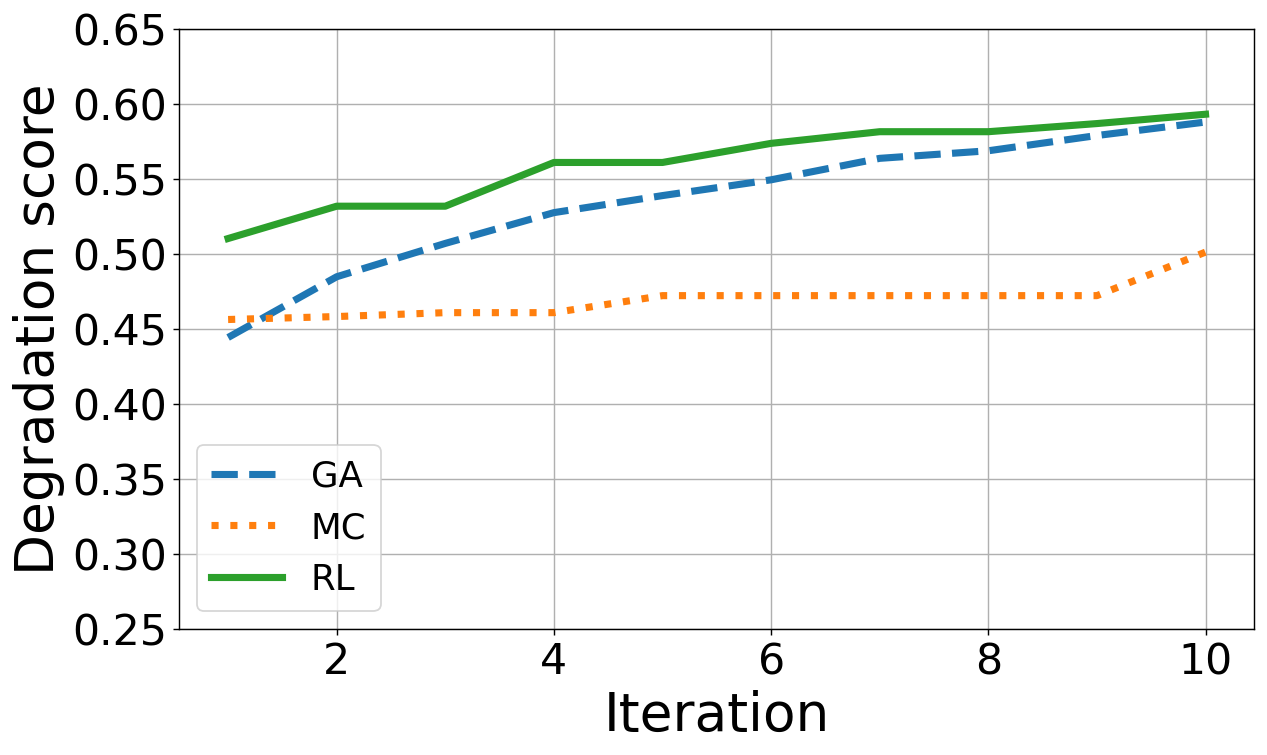

In [2]:
import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ===================== CONFIG =====================

base_dir = "./Data/Mix/"

pattern = re.compile(
    r"^(RL|Evo|MC)_Data_BestResults_\d+_"
    r"(Reggae|Country1|Disco|Beatles)\.csv$"
)


# ===================== LOAD FILES =====================

opt_data = {}   # optimiser -> dataset -> 1D np.array of scores
opt_dfs = {}    # optimiser -> dataset -> full DataFrame (for printing solutions)

for path in glob.glob(os.path.join(base_dir, "*_Data_BestResults_*.csv")):
    fname = os.path.basename(path)
    m = pattern.match(fname)
    if not m:
        # Skip files that don't match the naming convention
        continue

    optimiser, dataset = m.group(1), m.group(2)
    df = pd.read_csv(path)

    if "score" not in df.columns:
        raise ValueError(f"'score' column not found in {fname}")

    scores = df["score"].to_numpy()

    opt_data.setdefault(optimiser, {})[dataset] = scores
    opt_dfs.setdefault(optimiser, {})[dataset] = df  # store full df for later


# ===================== HELPER: BEST-UNTIL-CURRENT =====================

def best_until(scores: np.ndarray) -> np.ndarray:
    """
    Turn a per-iteration score array into a 'best so far' curve.
    """
    return np.maximum.accumulate(scores)


# ===================== COMPUTE AVERAGED CURVES =====================

avg_curves = {}
per_dataset_curves = {}

for optimiser, ds_dict in opt_data.items():
    if len(ds_dict) == 0:
        continue

    ds_curves = {}
    for dataset, scores in ds_dict.items():
        # If RL has more than 11 iterations, compress 2→1 until <= 11
        if optimiser == "RL_PPO":
            scores = compress_to_max_len(scores, max_len=11)

        # Now make the best-until-current curve
        ds_curves[dataset] = best_until(scores)

    # Align lengths across datasets (as before)
    lengths = [len(c) for c in ds_curves.values()]
    L = min(lengths)
    stacked = np.vstack([c[:L] for c in ds_curves.values()])
    avg_curve = stacked.mean(axis=0)

    avg_curves[optimiser] = avg_curve
    per_dataset_curves[optimiser] = {d: c[:L] for d, c in ds_curves.items()}

if "Evo" in avg_curves:
    evo_len = len(avg_curves["Evo"])

    # determine common minimum length
    common_length = min(len(avg_curves["MC"]), len(avg_curves["MC"]))

    if evo_len > common_length:
        print(f"Trimming Evo from {evo_len} → {common_length} iterations")
        avg_curves["Evo"] = avg_curves["Evo"][:common_length]

        # also trim per-dataset Evo curves (important!!)
        for ds in per_dataset_curves["Evo"]:
            per_dataset_curves["Evo"][ds] = per_dataset_curves["Evo"][ds][:common_length]

if "RL_PPO" in avg_curves:
    evo_len = len(avg_curves["RL_PPO"])

    # determine common minimum length
    common_length = min(len(avg_curves["MC"]), len(avg_curves["MC"]))

    if evo_len > common_length:
        print(f"Trimming Evo from {evo_len} → {common_length} iterations")
        avg_curves["RL_PPO"] = avg_curves["RL_PPO"][:common_length]

        # also trim per-dataset RL_PPO curves (important!!)
        for ds in per_dataset_curves["RL_PPO"]:
            per_dataset_curves["RL_PPO"][ds] = per_dataset_curves["RL_PPO"][ds][:common_length]


# ===================== BEST RESULT + FULL SOLUTION ROW =====================

best_per_dataset = {}      # optimiser -> dataset -> best raw score
best_rows_per_dataset = {} # optimiser -> dataset -> full row (Series)

for optimiser, ds_dict in opt_dfs.items():
    best_per_dataset[optimiser] = {}
    best_rows_per_dataset[optimiser] = {}

    for dataset, df_full in ds_dict.items():
        # Find the row with the maximum raw score in the original CSV
        idx_best = df_full["score"].idxmax()
        best_row = df_full.loc[idx_best]
        best_val = float(best_row["score"])

        best_per_dataset[optimiser][dataset] = best_val
        best_rows_per_dataset[optimiser][dataset] = best_row

print("\n=== Best raw score and solution per optimiser & dataset ===")
for optimiser in sorted(best_per_dataset.keys()):
    print(f"\nOptimiser: {optimiser}")
    for dataset in sorted(best_per_dataset[optimiser].keys()):
        val = best_per_dataset[optimiser][dataset]
        row = best_rows_per_dataset[optimiser][dataset]
        print(f"  {dataset}: best score = {val:.6f}")
        print(f"    solution: {row.to_dict()}")
        
records = []

for optimiser, ds_dict in opt_dfs.items():
    for dataset, df_full in ds_dict.items():
        idx = df_full["score"].idxmax()
        row = df_full.loc[idx]
        best_score = float(row["score"])

        # Build a single record
        rec = {"optimiser": optimiser, "dataset": dataset, "best_score": best_score}

        # Add every column from the CSV (parameters etc.)
        for col in df_full.columns:
            if col != "score":
                rec[col] = row[col]

        records.append(rec)

best_solution_df = pd.DataFrame(records)

print("\n=== BEST SOLUTION TABLE ===")
print(best_solution_df)

# ===================== PLOT AVERAGED CURVES =====================

plt.figure(figsize=(10,6), dpi=128)

# Line styles per optimiser
line_styles = {
    "RL": "-",
    "RL_PPO": "-",  # in case you use the key directly
    "Evo": "--",
    "MC": ":"
}

# Legend remapping
legend_map = {
    "RL_PPO": "RL",
    "Evo": "GA",
    "MC": "MC"
}

for optimiser, curve in sorted(avg_curves.items()):
    iters = np.arange(1, len(curve) + 1)
    style = line_styles.get(optimiser, "-")
    label = legend_map.get(optimiser, optimiser)
    plt.plot(iters, curve, style, linewidth=4, label=label)

plt.xlabel("Iteration",fontsize=30)
plt.ylabel("Degradation score",fontsize=30)
plt.ylim(0.25, 0.65)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
#plt.title("Average best-until-current-iteration across datasets (Speech)")
plt.grid(True)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

# ===================== (OPTIONAL) EXPORT RESULTS =====================

# If you want the numeric values for further analysis:
all_avg_df = []
for optimiser, curve in avg_curves.items():
    iters = np.arange(1, len(curve) + 1)
    tmp = pd.DataFrame({
        "optimiser": optimiser,
        "iteration": iters,
        "avg_best_until": curve,
    })
    all_avg_df.append(tmp)

all_avg_df = pd.concat(all_avg_df, ignore_index=True)
# Example: save to CSV
# all_avg_df.to_csv("Average_BestUntil_AllOptimisers.csv", index=False)


In [8]:
best_solution_df.to_csv("Best_Mix_solution_for_AllOptimisers.csv", index=False)